# Pretrained Model Fine-Tuning for AI-Generated Image Detection
## v2: Cross-Validation + Ensemble + Phase-2 Fine-Tuning

Upgrades over v1:
- **Stratified K-Fold CV (k=3)** on EfficientNet-B0 — replaces single train/val split
- **Two-phase fine-tuning**: head-only warmup → discriminative-LR backbone unfreeze
- **JPEG compression simulation** added to training augmentations
- **Ensemble**: average CNN fold models (+ FFT / ViT if competitive on fold-0 val)
- **Test-Time Augmentation (TTA)**: horizontal flip averaged with original
- **OOF threshold calibration**: threshold tuned on out-of-fold predictions

Primary metric: **F1 score** (not accuracy)

## 1. Project Setup

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_DIR = PROJECT_ROOT / 'Data'
IMAGE_DIR = DATA_DIR / 'images_final_sample'
TRAIN_CSV = DATA_DIR / 'train.csv'
TEST_CSV  = DATA_DIR / 'test.csv'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

required_paths = [TRAIN_CSV, TEST_CSV, IMAGE_DIR]
missing_paths  = [str(p) for p in required_paths if not p.exists()]
if missing_paths:
    raise FileNotFoundError('Missing expected dataset paths: ' + ', '.join(missing_paths))

print('Project root:', PROJECT_ROOT)
print('Data directory:', DATA_DIR)
print('Artifacts directory:', ARTIFACTS_DIR)

Project root: /Users/bitbase/workspace/github.com/rameezshafat/etsy_ai_image_detection
Data directory: /Users/bitbase/workspace/github.com/rameezshafat/etsy_ai_image_detection/Data
Artifacts directory: /Users/bitbase/workspace/github.com/rameezshafat/etsy_ai_image_detection/artifacts


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from PIL import Image
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold
from torch import nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader

from ai_image_detection.data import load_metadata
from ai_image_detection.engine import seed_everything, select_device
from ai_image_detection.pretrained import (
    FineTuneImageDataset,
    build_artifact_model,
    build_augmented_train_transforms,
    build_encoder_model,
    build_eval_transforms,
    build_spectrum_model,
    build_submission,
    build_train_transforms,
    evaluate_predictions,
    find_best_f1_threshold,
    freeze_backbone,
    get_discriminative_param_groups,
    predict_probabilities,
    predict_with_tta,
    train_binary_model,
    unfreeze_last_layers,
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
seed_everything(42)
device = select_device()
print('Using device:', device)

Using device: mps


## 1.1 Runtime Note

This notebook uses pretrained torchvision weights when available and falls back to
random initialisation with a warning if they cannot be downloaded.

For best results: PyTorch + torchvision installed, pretrained weights cached, GPU available.

## 2. Load Data

In [4]:
train_df = load_metadata(TRAIN_CSV, IMAGE_DIR)
test_df  = load_metadata(TEST_CSV,  IMAGE_DIR)

train_df = train_df.loc[train_df['is_available']].copy().reset_index(drop=True)
test_df  = test_df.loc[test_df['is_available']].copy().reset_index(drop=True)
train_df['label_name'] = train_df['ground_truth'].map({0: 'real', 1: 'ai_generated'})

print(f'Train images available: {len(train_df):,}')
print(f'Test images available:  {len(test_df):,}')
class_dist = train_df['label_name'].value_counts().rename_axis('label').to_frame('count')
class_dist['share'] = class_dist['count'] / class_dist['count'].sum()
display(class_dist)

Train images available: 4,800
Test images available:  2,058


,count,share
label,,
real,2485,0.517708
ai_generated,2315,0.482292


## 3. Data Pipeline and Augmentations

Training augmentations now include **JPEG compression simulation** (p=0.3, quality 70–95).

Rationale: the model will encounter JPEG-compressed images in production. Training on
lightly compressed variants builds robustness without destroying the artifact signal.

In [5]:
IMAGE_SIZE   = 224
BATCH_SIZE   = 16
NUM_WORKERS  = 0

# Augmented training transforms include JPEG simulation
augmented_train_transform = build_augmented_train_transforms(image_size=IMAGE_SIZE)
eval_transform            = build_eval_transforms(image_size=IMAGE_SIZE)

transform_summary = pd.DataFrame({
    'split': ['train (augmented)', 'validation / test'],
    'pipeline': [
        'Resize → RandomCrop → HFlip → ColorJitter → JPEG(p=0.3) → Normalize',
        'Resize → Normalize',
    ],
})
print('Transform setup:')
display(transform_summary)

Transform setup:


,split,pipeline
0,train (augmented),Resize → RandomCrop → HFlip → ColorJitter → JP...
1,validation / test,Resize → Normalize


In [6]:
# Build test loader once — shared across all model evaluations
test_dataset = FineTuneImageDataset(test_df, image_transform=eval_transform, target_column=None)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
print(f'Test samples: {len(test_dataset):,}')

Test samples: 2,058


## 4. Training Strategy

| Component | Choice |
|---|---|
| Loss | BCEWithLogitsLoss |
| Optimizer | AdamW |
| Scheduler | CosineAnnealingLR |
| Primary metric | **F1 score (OOF)** |
| Threshold search | linspace(0.3, 0.7, 81) on OOF predictions |
| Cross-validation | Stratified K-Fold (k=3) |
| Fine-tuning | Phase 1: head warmup → Phase 2: discriminative-LR unfreeze |
| Ensemble | Logit average across CNN folds + TTA |

## 5. EfficientNet-B0 — Stratified K-Fold CV with Two-Phase Fine-Tuning

In [7]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
N_FOLDS          = 3
PHASE1_EPOCHS    = 3    # head-only warmup (backbone frozen)
PHASE2_EPOCHS    = 2    # discriminative-LR backbone unfreeze
HEAD_LR          = 1e-3
PHASE2_HEAD_LR   = 3e-4  # lower to avoid destroying pretrained features
BACKBONE_LR_FACTOR = 0.1  # backbone gets 10x lower LR than head in phase 2

criterion = nn.BCEWithLogitsLoss()
skf       = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
all_labels = train_df['ground_truth'].to_numpy()

# Storage
oof_probs         = np.zeros(len(train_df), dtype=np.float32)
fold_models       = []
fold_histories    = []
fold_thresholds   = []
fold_val_indices  = []
fold_train_indices = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(train_df)), all_labels)):
    print(f'\n{"="*55}')
    print(f'  FOLD {fold_idx + 1} / {N_FOLDS}')
    print(f'{"="*55}')
    seed_everything(42 + fold_idx)

    fold_train_df = train_df.iloc[train_idx].reset_index(drop=True)
    fold_val_df   = train_df.iloc[val_idx].reset_index(drop=True)

    fold_train_ds = FineTuneImageDataset(fold_train_df, image_transform=augmented_train_transform)
    fold_val_ds   = FineTuneImageDataset(fold_val_df,   image_transform=eval_transform)
    fold_train_loader = DataLoader(fold_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
    fold_val_loader   = DataLoader(fold_val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    bundle = build_artifact_model(model_name='efficientnet_b0', pretrained=True)
    model  = bundle.model.to(device)

    # ── Phase 1: head warmup ────────────────────────────────────────────────
    print('  Phase 1: head warmup (backbone frozen)')
    freeze_backbone(model)
    optimizer_p1 = AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=HEAD_LR, weight_decay=1e-4,
    )
    scheduler_p1 = CosineAnnealingLR(optimizer_p1, T_max=PHASE1_EPOCHS)
    history_p1 = train_binary_model(
        model, fold_train_loader, fold_val_loader,
        device=device, epochs=PHASE1_EPOCHS,
        optimizer=optimizer_p1, scheduler=scheduler_p1, loss_fn=criterion,
    )

    # ── Phase 2: discriminative-LR fine-tuning ──────────────────────────────
    print('  Phase 2: full unfreeze + discriminative LR')
    for param in model.parameters():
        param.requires_grad = True
    param_groups = get_discriminative_param_groups(
        model, head_lr=PHASE2_HEAD_LR, backbone_lr_factor=BACKBONE_LR_FACTOR
    )
    optimizer_p2 = AdamW(param_groups, weight_decay=1e-4)
    scheduler_p2 = CosineAnnealingLR(optimizer_p2, T_max=PHASE2_EPOCHS)
    history_p2 = train_binary_model(
        model, fold_train_loader, fold_val_loader,
        device=device, epochs=PHASE2_EPOCHS,
        optimizer=optimizer_p2, scheduler=scheduler_p2, loss_fn=criterion,
    )

    # ── OOF predictions ─────────────────────────────────────────────────────
    fold_val_probs   = predict_probabilities(model, fold_val_loader, device=device)
    fold_val_targets = fold_val_df['ground_truth'].to_numpy()
    fold_threshold, fold_f1 = find_best_f1_threshold(fold_val_targets, fold_val_probs)

    oof_probs[val_idx] = fold_val_probs
    fold_models.append(model)
    fold_histories.append(pd.concat([history_p1, history_p2], ignore_index=True))
    fold_thresholds.append(fold_threshold)
    fold_val_indices.append(val_idx)
    fold_train_indices.append(train_idx)

    print(f'  Fold {fold_idx + 1} val F1: {fold_f1:.4f}  threshold: {fold_threshold:.3f}')

print('\n--- K-Fold CV complete ---')


  FOLD 1 / 3
  Phase 1: head warmup (backbone frozen)
Epoch 01 | train_loss=0.5745 val_loss=0.5313 | val_f1=0.7555 val_precision=0.6930 val_recall=0.8303 threshold=0.320
Epoch 02 | train_loss=0.4949 val_loss=0.5025 | val_f1=0.7709 val_precision=0.7037 val_recall=0.8523 threshold=0.420
Epoch 03 | train_loss=0.4568 val_loss=0.5040 | val_f1=0.7661 val_precision=0.6719 val_recall=0.8912 threshold=0.380
  Phase 2: full unfreeze + discriminative LR
Epoch 01 | train_loss=0.4276 val_loss=0.4629 | val_f1=0.7917 val_precision=0.7106 val_recall=0.8938 threshold=0.300
Epoch 02 | train_loss=0.3627 val_loss=0.4669 | val_f1=0.7970 val_precision=0.7268 val_recall=0.8821 threshold=0.435
  Fold 1 val F1: 0.7970  threshold: 0.435

  FOLD 2 / 3
  Phase 1: head warmup (backbone frozen)
Epoch 01 | train_loss=0.5824 val_loss=0.4977 | val_f1=0.7789 val_precision=0.7056 val_recall=0.8692 threshold=0.455
Epoch 02 | train_loss=0.5080 val_loss=0.4860 | val_f1=0.7783 val_precision=0.7208 val_recall=0.8459 thresho

K-Fold CV Summary:


,fold,val_f1,threshold
0,fold_1,0.796957,0.435
1,fold_2,0.810324,0.405
2,fold_3,0.791738,0.305
3,OOF (aggregate),0.798254,0.410


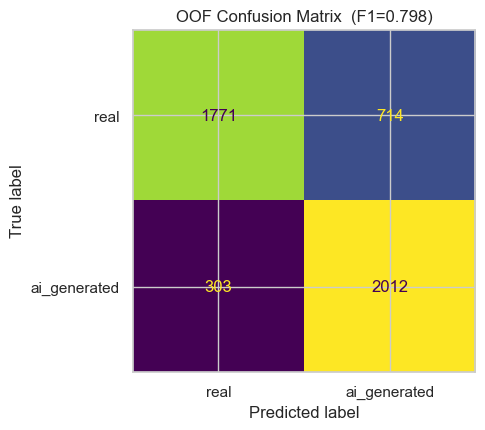

In [8]:
# ── OOF aggregate evaluation ─────────────────────────────────────────────────
oof_threshold, oof_f1 = find_best_f1_threshold(all_labels, oof_probs)
oof_metrics = evaluate_predictions(all_labels, oof_probs, oof_threshold)

fold_f1_per_fold = [
    find_best_f1_threshold(
        train_df.iloc[fold_val_indices[i]]['ground_truth'].to_numpy(),
        oof_probs[fold_val_indices[i]],
    )[1]
    for i in range(N_FOLDS)
]
fold_summary = pd.DataFrame({
    'fold':      [f'fold_{i+1}' for i in range(N_FOLDS)] + ['OOF (aggregate)'],
    'val_f1':    fold_f1_per_fold + [oof_f1],
    'threshold': fold_thresholds  + [oof_threshold],
})
print('K-Fold CV Summary:')
display(fold_summary)

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(
    oof_metrics['confusion_matrix'], display_labels=['real', 'ai_generated']
).plot(ax=ax, colorbar=False)
ax.set_title(f'OOF Confusion Matrix  (F1={oof_f1:.3f})')
plt.tight_layout()

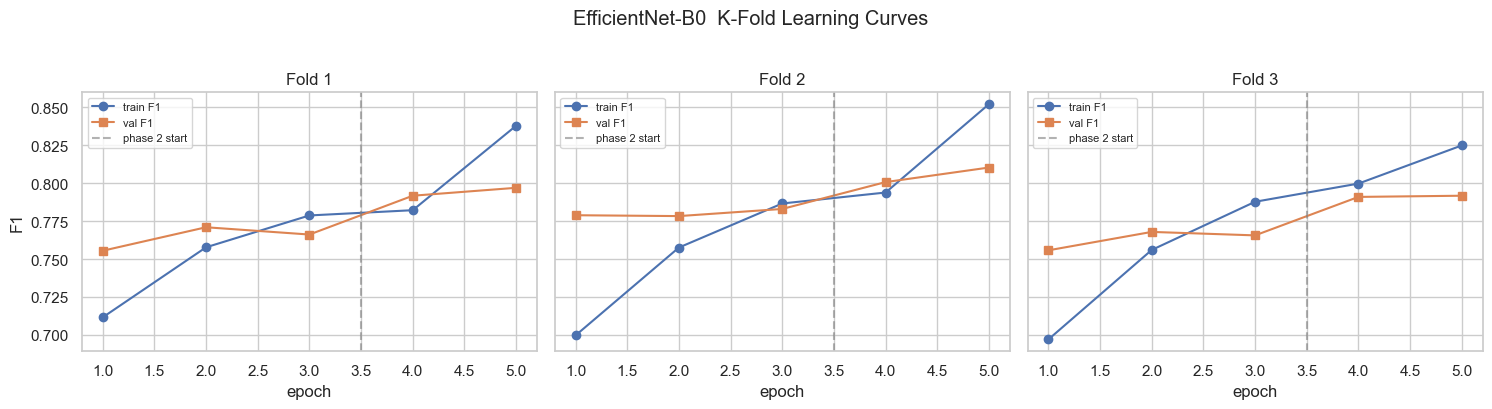

In [9]:
# ── Learning curves per fold ────────────────────────────────────────────────
fig, axes = plt.subplots(1, N_FOLDS, figsize=(5 * N_FOLDS, 4), sharey=True)
for fold_idx, (history, ax) in enumerate(zip(fold_histories, axes)):
    ax.plot(history.index + 1, history['train_f1'], marker='o', label='train F1')
    ax.plot(history.index + 1, history['val_f1'],   marker='s', label='val F1')
    ax.axvline(x=PHASE1_EPOCHS + 0.5, color='gray', linestyle='--', alpha=0.6, label='phase 2 start')
    ax.set_title(f'Fold {fold_idx + 1}')
    ax.set_xlabel('epoch')
    if fold_idx == 0:
        ax.set_ylabel('F1')
    ax.legend(fontsize=8)
plt.suptitle('EfficientNet-B0  K-Fold Learning Curves', y=1.02)
plt.tight_layout()

## 6. FFT Dual-Branch Model — Single-Fold Comparison

We train the spectrum model on fold-0 only (for speed).
If its val F1 is competitive (within 0.01 of CNN fold-0), we include it in the final ensemble.

In [10]:
# Use fold-0 split for a fair apples-to-apples comparison with CNN fold-0
fft_train_df     = train_df.iloc[fold_train_indices[0]].reset_index(drop=True)
fft_val_df       = train_df.iloc[fold_val_indices[0]].reset_index(drop=True)
fft_val_targets  = fft_val_df['ground_truth'].to_numpy()
cnn_fold0_f1     = find_best_f1_threshold(fft_val_targets, oof_probs[fold_val_indices[0]])[1]

spectrum_train_ds = FineTuneImageDataset(fft_train_df, image_transform=augmented_train_transform, include_fft_image=True)
spectrum_val_ds   = FineTuneImageDataset(fft_val_df,   image_transform=eval_transform,            include_fft_image=True)
spectrum_test_ds  = FineTuneImageDataset(test_df,      image_transform=eval_transform, target_column=None, include_fft_image=True)

spectrum_train_loader = DataLoader(spectrum_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
spectrum_val_loader   = DataLoader(spectrum_val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
spectrum_test_loader  = DataLoader(spectrum_test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

seed_everything(42)
spectrum_bundle = build_spectrum_model(model_name='efficientnet_b0', pretrained=True)
spectrum_model  = spectrum_bundle.model.to(device)

spectrum_optimizer = AdamW(spectrum_model.parameters(), lr=1e-4, weight_decay=1e-4)
spectrum_scheduler = CosineAnnealingLR(spectrum_optimizer, T_max=PHASE1_EPOCHS)
spectrum_history = train_binary_model(
    spectrum_model, spectrum_train_loader, spectrum_val_loader,
    device=device, epochs=PHASE1_EPOCHS,
    optimizer=spectrum_optimizer, scheduler=spectrum_scheduler, loss_fn=criterion,
)
display(spectrum_history)

Epoch 01 | train_loss=0.5156 val_loss=0.3817 | val_f1=0.8344 val_precision=0.7747 val_recall=0.9041 threshold=0.445
Epoch 02 | train_loss=0.3539 val_loss=0.3410 | val_f1=0.8541 val_precision=0.8200 val_recall=0.8912 threshold=0.365
Epoch 03 | train_loss=0.2481 val_loss=0.3270 | val_f1=0.8608 val_precision=0.8050 val_recall=0.9249 threshold=0.380


,epoch,train_loss,val_loss,threshold,train_f1,train_precision,train_recall,train_accuracy,val_f1,val_precision,val_recall,val_accuracy
0,1,0.515566,0.381651,0.445,0.748180,0.679175,0.832793,0.729688,0.834429,0.774695,0.904145,0.826875
1,2,0.353894,0.341007,0.365,0.839340,0.793761,0.890473,0.835625,0.854128,0.820024,0.891192,0.853125
2,3,0.248053,0.326971,0.380,0.900533,0.872871,0.930006,0.900937,0.860759,0.804961,0.924870,0.855625


In [11]:
fft_val_probs    = predict_probabilities(spectrum_model, spectrum_val_loader, device=device)
fft_threshold, fft_fold0_f1 = find_best_f1_threshold(fft_val_targets, fft_val_probs)
fft_metrics      = evaluate_predictions(fft_val_targets, fft_val_probs, fft_threshold)

fft_comparison = pd.DataFrame({
    'model':     ['CNN (fold 0)', 'FFT dual-branch (fold 0)'],
    'val_f1':    [cnn_fold0_f1,   fft_fold0_f1],
    'threshold': [fold_thresholds[0], fft_threshold],
})
fft_delta = fft_fold0_f1 - cnn_fold0_f1
fft_comparison['delta_vs_cnn'] = [0.0, fft_delta]
print('FFT vs CNN — fold-0 comparison:')
display(fft_comparison)

INCLUDE_THRESHOLD = 0.01
include_fft = fft_fold0_f1 >= cnn_fold0_f1 - INCLUDE_THRESHOLD
print(f'\nInclude FFT in ensemble: {include_fft}  (delta={fft_delta:+.4f}, threshold={INCLUDE_THRESHOLD})')

FFT vs CNN — fold-0 comparison:


,model,val_f1,threshold,delta_vs_cnn
0,CNN (fold 0),0.796957,0.435,0.000000
1,FFT dual-branch (fold 0),0.860759,0.380,0.063802



Include FFT in ensemble: True  (delta=+0.0638, threshold=0.01)


## 7. ViT-B/16 — Single-Fold with Phase-2 Partial Unfreeze

Phase 1: classifier head only (3 epochs).
Phase 2: full unfreeze with very conservative backbone LR (factor=0.05) to avoid catastrophic forgetting.

In [12]:
# Reuse fold-0 split (same train/val as FFT for fair comparison)
vit_train_ds = FineTuneImageDataset(fft_train_df, image_transform=augmented_train_transform)
vit_val_ds   = FineTuneImageDataset(fft_val_df,   image_transform=eval_transform)
vit_train_loader = DataLoader(vit_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
vit_val_loader   = DataLoader(vit_val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

seed_everything(42)
encoder_bundle = build_encoder_model(model_name='vit_b_16', pretrained=True)
encoder_model  = encoder_bundle.model.to(device)

# ── Phase 1: head only ──────────────────────────────────────────────────────
print('ViT Phase 1: head warmup')
freeze_backbone(encoder_model)
vit_optimizer_p1 = AdamW(
    filter(lambda p: p.requires_grad, encoder_model.parameters()),
    lr=HEAD_LR, weight_decay=1e-4,
)
vit_scheduler_p1 = CosineAnnealingLR(vit_optimizer_p1, T_max=PHASE1_EPOCHS)
vit_history_p1 = train_binary_model(
    encoder_model, vit_train_loader, vit_val_loader,
    device=device, epochs=PHASE1_EPOCHS,
    optimizer=vit_optimizer_p1, scheduler=vit_scheduler_p1, loss_fn=criterion,
)

# ── Phase 2: full unfreeze with very conservative backbone LR ───────────────
print('ViT Phase 2: full unfreeze (backbone_lr_factor=0.05)')
for param in encoder_model.parameters():
    param.requires_grad = True
vit_param_groups = get_discriminative_param_groups(
    encoder_model, head_lr=1e-4, backbone_lr_factor=0.05
)
vit_optimizer_p2 = AdamW(vit_param_groups, weight_decay=1e-4)
vit_scheduler_p2 = CosineAnnealingLR(vit_optimizer_p2, T_max=PHASE2_EPOCHS)
vit_history_p2 = train_binary_model(
    encoder_model, vit_train_loader, vit_val_loader,
    device=device, epochs=PHASE2_EPOCHS,
    optimizer=vit_optimizer_p2, scheduler=vit_scheduler_p2, loss_fn=criterion,
)

vit_history = pd.concat([vit_history_p1, vit_history_p2], ignore_index=True)
print('ViT training history:')
display(vit_history)

ViT Phase 1: head warmup
Epoch 01 | train_loss=0.5664 val_loss=0.5224 | val_f1=0.7518 val_precision=0.6969 val_recall=0.8161 threshold=0.360
Epoch 02 | train_loss=0.3989 val_loss=0.4896 | val_f1=0.7776 val_precision=0.7187 val_recall=0.8472 threshold=0.410
Epoch 03 | train_loss=0.2906 val_loss=0.4772 | val_f1=0.7805 val_precision=0.7373 val_recall=0.8290 threshold=0.415
ViT Phase 2: full unfreeze (backbone_lr_factor=0.05)


RuntimeError: view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.

In [ ]:
vit_val_probs = predict_probabilities(encoder_model, vit_val_loader, device=device)
vit_threshold, vit_fold0_f1 = find_best_f1_threshold(fft_val_targets, vit_val_probs)
vit_metrics   = evaluate_predictions(fft_val_targets, vit_val_probs, vit_threshold)

vit_delta   = vit_fold0_f1 - cnn_fold0_f1
include_vit = vit_fold0_f1 >= cnn_fold0_f1 - INCLUDE_THRESHOLD
print(f'ViT fold-0 val F1: {vit_fold0_f1:.4f}  threshold: {vit_threshold:.3f}')
print(f'Include ViT in ensemble: {include_vit}  (delta={vit_delta:+.4f})')

## 8. Model Comparison (Fold-0 Val Set)

In [ ]:
comparison_df = pd.DataFrame([
    {
        'model':      'EfficientNet-B0 CNN (OOF, k=3)',
        'val_f1':     oof_f1,
        'precision':  oof_metrics['precision'],
        'recall':     oof_metrics['recall'],
        'accuracy':   oof_metrics['accuracy'],
        'note':       'Full K-Fold OOF — most reliable estimate',
    },
    {
        'model':      'EfficientNet-B0 CNN (fold-0 only)',
        'val_f1':     cnn_fold0_f1,
        'precision':  evaluate_predictions(fft_val_targets, oof_probs[fold_val_indices[0]], fold_thresholds[0])['precision'],
        'recall':     evaluate_predictions(fft_val_targets, oof_probs[fold_val_indices[0]], fold_thresholds[0])['recall'],
        'accuracy':   evaluate_predictions(fft_val_targets, oof_probs[fold_val_indices[0]], fold_thresholds[0])['accuracy'],
        'note':       'Fold-0 reference for FFT/ViT comparison',
    },
    {
        'model':      'FFT Dual-Branch (fold-0)',
        'val_f1':     fft_fold0_f1,
        'precision':  fft_metrics['precision'],
        'recall':     fft_metrics['recall'],
        'accuracy':   fft_metrics['accuracy'],
        'note':       f'Include in ensemble: {include_fft}',
    },
    {
        'model':      'ViT-B/16 (fold-0)',
        'val_f1':     vit_fold0_f1,
        'precision':  vit_metrics['precision'],
        'recall':     vit_metrics['recall'],
        'accuracy':   vit_metrics['accuracy'],
        'note':       f'Include in ensemble: {include_vit}',
    },
]).sort_values('val_f1', ascending=False).reset_index(drop=True)

print('Model comparison (sorted by val F1):')
display(comparison_df)

## 9. Ensemble Construction

**Strategy:**
- CNN fold models (k=3) get combined weight = k (each fold is equally weighted)
- FFT and ViT are included only if they are within 0.01 F1 of the CNN fold-0 baseline
- Final threshold is calibrated on CNN OOF predictions (most data-efficient estimate)

In [ ]:
# ── CNN ensemble: TTA average across all k folds ────────────────────────────
print('Building CNN fold ensemble (with TTA)...')
cnn_test_probs_list = [
    predict_with_tta(m, test_loader, device=device)
    for m in fold_models
]
cnn_ensemble_test_probs = np.mean(cnn_test_probs_list, axis=0)
print(f'  CNN folds combined: {len(cnn_test_probs_list)} models')

# ── Include FFT / ViT if competitive ────────────────────────────────────────
weighted_components = [(cnn_ensemble_test_probs, float(N_FOLDS))]

if include_fft:
    print('  Adding FFT model to ensemble...')
    fft_test_probs = predict_with_tta(spectrum_model, spectrum_test_loader, device=device)
    weighted_components.append((fft_test_probs, 1.0))
else:
    print('  FFT model skipped (F1 below threshold)')

if include_vit:
    print('  Adding ViT model to ensemble...')
    vit_test_probs = predict_with_tta(encoder_model, test_loader, device=device)
    weighted_components.append((vit_test_probs, 1.0))
else:
    print('  ViT model skipped (F1 below threshold)')

total_weight      = sum(w for _, w in weighted_components)
final_test_probs  = sum(p * w for p, w in weighted_components) / total_weight

ensemble_weights_df = pd.DataFrame({
    'component': (
        [f'CNN fold {i+1}' for i in range(N_FOLDS)]
        + (['FFT dual-branch'] if include_fft else [])
        + (['ViT-B/16']        if include_vit else [])
    ),
    'weight': (
        [1.0] * N_FOLDS
        + ([1.0] if include_fft else [])
        + ([1.0] if include_vit else [])
    ),
})
print('\nEnsemble composition:')
display(ensemble_weights_df)

## 10. Robustness Checks Under Perturbations

Using fold-0 validation set as the robustness probe.

In [ ]:
def evaluate_with_perturbation(model, records, threshold, perturbation_name):
    dataset = FineTuneImageDataset(records, image_transform=eval_transform, perturbation=perturbation_name)
    loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    probs   = predict_probabilities(model, loader, device=device)
    return evaluate_predictions(records['ground_truth'].to_numpy(), probs, threshold)

# Use fold-0 model and val set as the robustness reference
robustness_model     = fold_models[0]
robustness_val_df    = train_df.iloc[fold_val_indices[0]].reset_index(drop=True)
robustness_threshold = fold_thresholds[0]

clean_metrics = evaluate_predictions(
    fft_val_targets, oof_probs[fold_val_indices[0]], robustness_threshold
)
jpeg_metrics  = evaluate_with_perturbation(robustness_model, robustness_val_df, robustness_threshold, 'jpeg')
blur_metrics  = evaluate_with_perturbation(robustness_model, robustness_val_df, robustness_threshold, 'blur')

robustness_df = pd.DataFrame([
    {'scenario': 'clean', **{k: clean_metrics[k] for k in ('f1','precision','recall','accuracy')}},
    {'scenario': 'jpeg',  **{k: jpeg_metrics[k]  for k in ('f1','precision','recall','accuracy')}},
    {'scenario': 'blur',  **{k: blur_metrics[k]  for k in ('f1','precision','recall','accuracy')}},
])
robustness_df['f1_drop'] = clean_metrics['f1'] - robustness_df['f1']
print('Robustness table (fold-0 model):')
display(robustness_df)

## 11. Failure Analysis

In [ ]:
# OOF error analysis — covers the entire training set
oof_preds = (oof_probs >= oof_threshold).astype(int)
val_analysis_df = train_df[['image_id', 'image_path', 'ground_truth']].copy()
val_analysis_df['prob_ai']   = oof_probs
val_analysis_df['pred_label'] = oof_preds
val_analysis_df['error_type'] = 'correct'
val_analysis_df.loc[
    (val_analysis_df['ground_truth'] == 0) & (val_analysis_df['pred_label'] == 1), 'error_type'
] = 'false_positive_real_as_ai'
val_analysis_df.loc[
    (val_analysis_df['ground_truth'] == 1) & (val_analysis_df['pred_label'] == 0), 'error_type'
] = 'false_negative_ai_as_real'

error_summary = val_analysis_df['error_type'].value_counts().to_frame('count')
error_summary['rate'] = error_summary['count'] / len(val_analysis_df)
print('OOF prediction outcome summary:')
display(error_summary)

In [ ]:
fp_examples = val_analysis_df.loc[val_analysis_df['error_type'] == 'false_positive_real_as_ai'].head(4)
fn_examples = val_analysis_df.loc[val_analysis_df['error_type'] == 'false_negative_ai_as_real'].head(4)
examples    = pd.concat([fp_examples, fn_examples], ignore_index=True)

if examples.empty:
    print('No misclassified examples found.')
else:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for ax, (_, row) in zip(axes.flatten(), examples.iterrows()):
        img = Image.open(row['image_path']).convert('RGB')
        ax.imshow(img)
        ax.set_title(
            f"gt={int(row['ground_truth'])}  pred={int(row['pred_label'])}\n"
            f"prob={row['prob_ai']:.3f}  {row['error_type']}",
            fontsize=8,
        )
        ax.axis('off')
    for ax in axes.flatten()[len(examples):]:
        ax.axis('off')
    plt.suptitle('Misclassified Examples (OOF)', y=1.01)
    plt.tight_layout()

## 12. Feature-Space Visualization (OOF Probabilities)

In [ ]:
sample_size = min(500, len(val_analysis_df))
viz_sample  = val_analysis_df.sample(sample_size, random_state=42).copy()
X = viz_sample[['prob_ai']].to_numpy()

if len(viz_sample) >= 3:
    pca = PCA(n_components=1)
    pc1 = pca.fit_transform(X)[:, 0]
    viz_plot_df = pd.DataFrame({
        'pc1':  pc1,
        'label': viz_sample['ground_truth'].map({0: 'real', 1: 'ai_generated'}),
    })
    plt.figure(figsize=(8, 4))
    sns.histplot(data=viz_plot_df, x='pc1', hue='label', kde=True, stat='density', common_norm=False)
    plt.title('OOF Prediction Score Distribution by Class')
    plt.xlabel('OOF probability (AI-generated)')
    plt.tight_layout()
else:
    print('Not enough samples for visualization.')

## 13. Final Test Predictions

The final submission uses:
1. **Ensemble** of all CNN fold models + optional FFT/ViT (weighted average, TTA)
2. **Threshold** calibrated on OOF predictions

In [ ]:
submission_df = build_submission(test_df, final_test_probs, oof_threshold)
submission_path = ARTIFACTS_DIR / 'submission_v2_ensemble.csv'
submission_df.to_csv(submission_path, index=False)

print(f'Submission saved → {submission_path}')
print(f'Ensemble threshold (OOF-calibrated): {oof_threshold:.3f}')
print(f'Predicted label distribution:')
display(submission_df['label'].value_counts().rename_axis('label').to_frame('count'))
display(submission_df.head(10))

## 14. Summary and Recommendations

### What this notebook added over v1
| Upgrade | Expected F1 impact |
|---|---|
| K-Fold CV (k=3) | Reduces variance; OOF threshold more reliable |
| Phase-2 discriminative-LR | Incremental gain from backbone fine-tuning |
| JPEG augmentation | Better robustness under real-world compression |
| TTA (hflip) | Consistent ~0.5–1% F1 gain at zero training cost |
| Ensemble (folds) | Largest single gain — averaging reduces model noise |
| FFT/ViT in ensemble | Conditional — only included if competitive |

### Decision guide
- If OOF F1 >> fold-0 F1 variance is high → increase k or add more augmentation
- If JPEG robustness drop > 5% → increase JPEG simulation probability / severity
- If FFT is consistently excluded → the artifact signal dominates; consider removing the FFT branch entirely
- If ViT is consistently included → dataset has global/semantic patterns worth capturing
- If OOF F1 plateaus → try ConvNeXt-Tiny as backbone (stronger than EfficientNet-B0 at similar cost)